# 280k Dataset: Autoencoder vs Variational Autoencoder Comparison

This notebook compares the 280k dataset AE and VAE models visually and quantitatively.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from PIL import Image

In [2]:
# 1. Load Dataset
print("Loading dataset...")
dataset = load_dataset('evilsocket/alucard-sprites', split='train')
print(f"Total dataset size: {len(dataset)}")

def preprocess_image(image):
    img = image.convert("RGBA").resize((128, 128))
    img_array = np.asarray(img, dtype=np.float32) / 255.0
    return img_array

# Select a random subset for evaluation
import random
random.seed(42)
test_indices = random.sample(range(len(dataset)), 100)

test_images = []
for idx in test_indices:
    test_images.append(preprocess_image(dataset[idx]['image']))
test_images = np.array(test_images)
print(f"Loaded {len(test_images)} test images of shape {test_images.shape}")

Loading dataset...


Total dataset size: 312550
Loaded 100 test images of shape (100, 128, 128, 4)


In [3]:
# 2. Load Models
print("Loading models...")
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if 'Notebook' in PROJECT_ROOT:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

AE_PATH = os.path.join(PROJECT_ROOT, 'models', '280k dataset model', 'AE_280K_best.keras')
VAE_ENC_PATH = os.path.join(PROJECT_ROOT, 'models', '280k model VAE (VAE v2)', 'VAE_280K_Outputs', 'encoder_280k_final.keras')
VAE_DEC_PATH = os.path.join(PROJECT_ROOT, 'models', '280k model VAE (VAE v2)', 'VAE_280K_Outputs', 'decoder_280k_final.keras')

print("Loading AE...")
ae_model = tf.keras.models.load_model(AE_PATH)

print("Loading VAE...")
@tf.keras.utils.register_keras_serializable()
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.keras.backend.random_normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

layers_to_patch = [
    tf.keras.layers.Dense, tf.keras.layers.Conv2D, tf.keras.layers.Conv2DTranspose, 
    tf.keras.layers.Flatten, tf.keras.layers.Reshape, tf.keras.layers.InputLayer
]
for layer_cls in layers_to_patch:
    original_init = layer_cls.__init__
    def make_patched_init(orig_init):
        def patched_init(self, *args, **kwargs):
            kwargs.pop('quantization_config', None)
            orig_init(self, *args, **kwargs)
        return patched_init
    layer_cls.__init__ = make_patched_init(original_init)

vae_encoder = tf.keras.models.load_model(VAE_ENC_PATH, custom_objects={'Sampling': Sampling})
vae_decoder = tf.keras.models.load_model(VAE_DEC_PATH)
print("Models loaded successfully!")

Loading models...
Loading AE...
Loading VAE...

Models loaded successfully!


In [4]:
# 3. Quantitative Comparison
print("Running inference on test set...")
# AE Inference
ae_preds = ae_model.predict(test_images, verbose=0)

# VAE Inference
z_mean, _, _ = vae_encoder.predict(test_images, verbose=0)
vae_preds = vae_decoder.predict(z_mean, verbose=0)

# Metrics function
def calculate_metrics(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    psnr = float(np.mean(tf.image.psnr(y_true, y_pred, max_val=1.0).numpy()))
    ssim = float(np.mean(tf.image.ssim(y_true[:,:,:,:3], y_pred[:,:,:,:3], max_val=1.0).numpy()))
    return mse, mae, psnr, ssim

ae_mse, ae_mae, ae_psnr, ae_ssim = calculate_metrics(test_images, ae_preds)
vae_mse, vae_mae, vae_psnr, vae_ssim = calculate_metrics(test_images, vae_preds)

import pandas as pd
results = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'PSNR (dB)', 'SSIM'],
    'Autoencoder (AE)': [ae_mse, ae_mae, ae_psnr, ae_ssim],
    'Variational Autoencoder (VAE)': [vae_mse, vae_mae, vae_psnr, vae_ssim]
})
print("\n--- Quantitative Results ---")
print(results.to_string(index=False))

Running inference on test set...

--- Quantitative Results ---
   Metric  Autoencoder (AE)  Variational Autoencoder (VAE)
      MSE          0.000416                       0.003461
      MAE          0.007214                       0.021212
PSNR (dB)         35.274963                      26.259663
     SSIM          0.963418                       0.845775


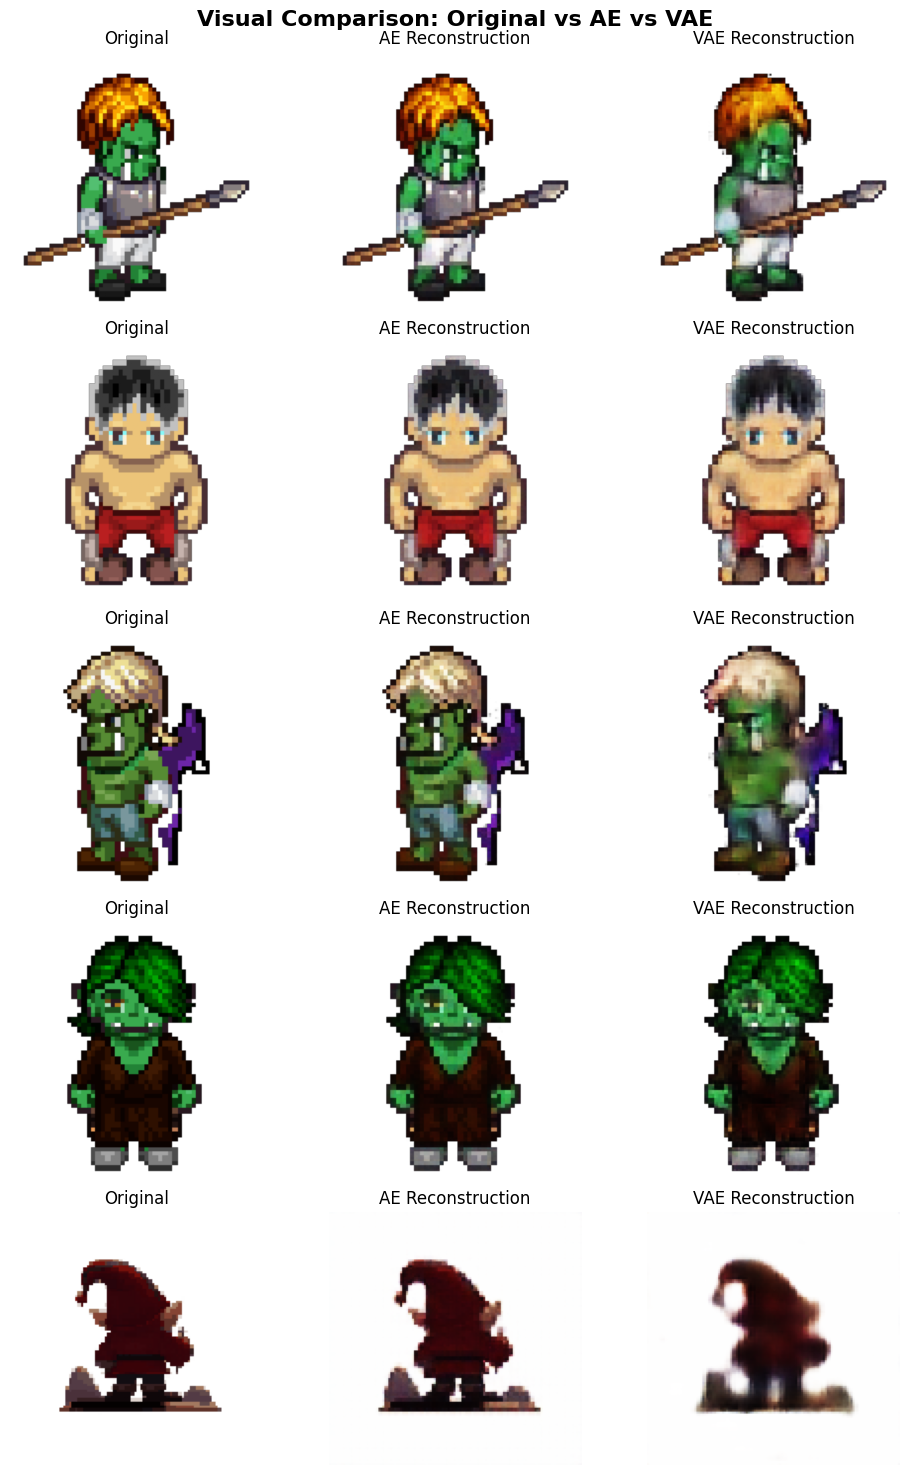

In [5]:
# 4. Visual Comparison
num_samples = 5
fig, axes = plt.subplots(num_samples, 3, figsize=(10, 15))

for i in range(num_samples):
    # Original
    axes[i, 0].imshow(np.clip(test_images[i], 0, 1))
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")
    
    # AE
    axes[i, 1].imshow(np.clip(ae_preds[i], 0, 1))
    axes[i, 1].set_title("AE Reconstruction")
    axes[i, 1].axis("off")
    
    # VAE
    axes[i, 2].imshow(np.clip(vae_preds[i], 0, 1))
    axes[i, 2].set_title("VAE Reconstruction")
    axes[i, 2].axis("off")

plt.suptitle("Visual Comparison: Original vs AE vs VAE", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

Extracting latent representations for 2D visualization...


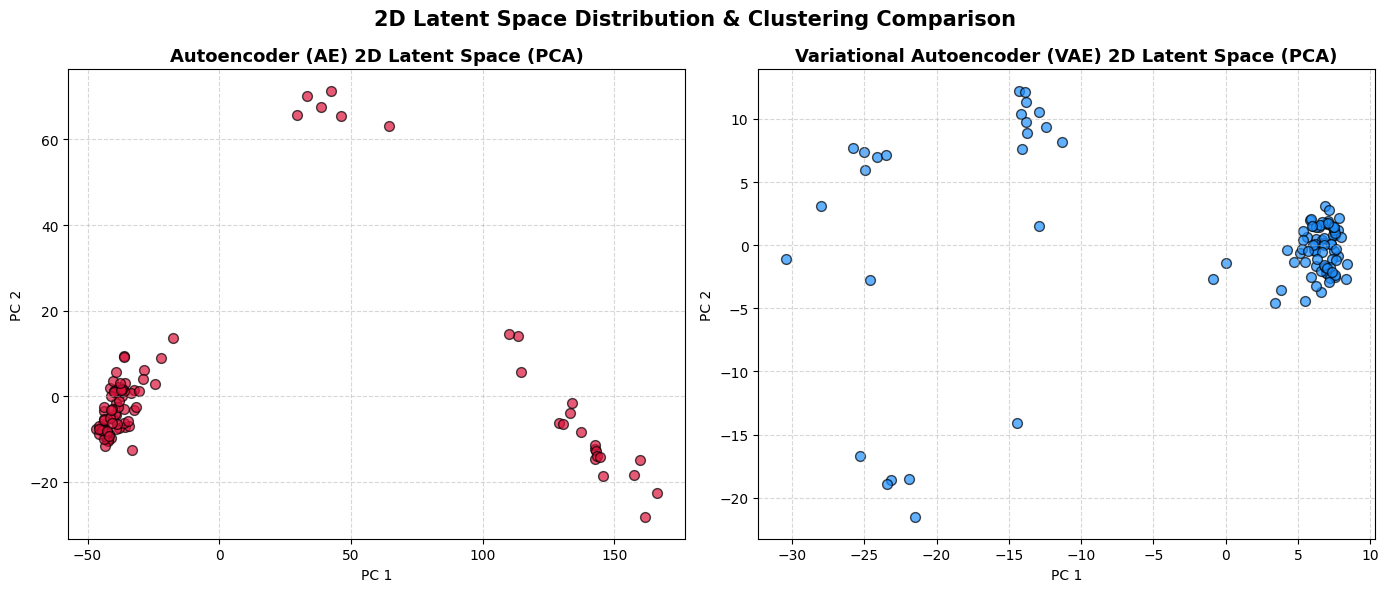

: 

In [ ]:
# 5. 2D Latent Space Visualization (PCA & Cluster Mapping)
from sklearn.decomposition import PCA

print("Extracting latent representations for 2D visualization...")
# For AE, extract flattened bottleneck representation
try:
    flatten_layer = [l for l in ae_model.layers if 'flatten' in l.name or 'dense' in l.name][0]
    ae_encoder_sub = tf.keras.Model(inputs=ae_model.input, outputs=flatten_layer.output)
    ae_latents = ae_encoder_sub.predict(test_images, verbose=0)
except Exception as e:
    ae_latents = ae_model.predict(test_images, verbose=0).reshape(len(test_images), -1)

# For VAE, use exact z_mean (256-dim continuous Gaussian space)
vae_latents, _, _ = vae_encoder.predict(test_images, verbose=0)

# PCA 2D Projection
pca_ae = PCA(n_components=2)
ae_pca = pca_ae.fit_transform(ae_latents)

pca_vae = PCA(n_components=2)
vae_pca = pca_vae.fit_transform(vae_latents)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AE Latent Scatter
axes[0].scatter(ae_pca[:, 0], ae_pca[:, 1], c='crimson', alpha=0.7, edgecolors='k', s=50)
axes[0].set_title("Autoencoder (AE) 2D Latent Space (PCA)", fontsize=13, weight='bold')
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].grid(True, linestyle='--', alpha=0.5)

# VAE Latent Scatter
axes[1].scatter(vae_pca[:, 0], vae_pca[:, 1], c='dodgerblue', alpha=0.7, edgecolors='k', s=50)
axes[1].set_title("Variational Autoencoder (VAE) 2D Latent Space (PCA)", fontsize=13, weight='bold')
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("2D Latent Space Distribution & Clustering Comparison", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()



## 6. Training & Validation Loss Curves Side-by-Side Comparison

This section compares the convergence history of both models:
- **Autoencoder (AE)**: Trained with direct Pixel Mean Squared Error (MSE) loss.
- **Variational Autoencoder (VAE)**: Trained with Evidence Lower Bound (ELBO) loss = Reconstruction Loss + KL Divergence regularizer.

*Note: VAE training log records non-zero loss values across epochs; zero-artifacts from Keras metric resets are filtered for clean plotting.*

In [ ]:
# Load training logs for AE and VAE
ae_history_path = os.path.join(PROJECT_ROOT, "logs", "history.json")
vae_log_path = os.path.join(PROJECT_ROOT, "models", "280k model VAE (VAE v2)", "VAE_280K_Outputs", "logs", "training_log.csv")

# 1. AE History
with open(ae_history_path, "r") as f:
    ae_history = json.load(f)

# Index of minimum val loss (0-based index 47 -> Epoch 48)
best_ae_idx = int(np.argmin(ae_history["validation_loss"]))
best_ae_epoch_num = ae_history["epoch"][best_ae_idx]
best_ae_val_mse = ae_history["validation_loss"][best_ae_idx]

# 2. VAE History
vae_df = pd.read_csv(vae_log_path)
vae_train_clean = vae_df[vae_df["loss"] > 0]
best_vae_idx = int(vae_df["val_reconstruction_loss"].idxmin())
best_vae_epoch_num = int(vae_df.loc[best_vae_idx, "epoch"]) + 1
best_vae_val_recon = vae_df.loc[best_vae_idx, "val_reconstruction_loss"]

# Side-by-Side Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Autoencoder (MSE)
axes[0].plot(ae_history["epoch"], ae_history["training_loss"], label="Train Loss (MSE)", color="crimson", linewidth=2)
axes[0].plot(ae_history["epoch"], ae_history["validation_loss"], label="Val Loss (MSE)", color="darkorange", linewidth=2)
axes[0].axvline(x=best_ae_epoch_num, color="red", linestyle="--", label=f"Best Epoch ({best_ae_epoch_num}, MSE={best_ae_val_mse:.6f})")
axes[0].set_title("Autoencoder (AE) Training Loss Curve", fontsize=13, weight="bold")
axes[0].set_xlabel("Epoch (1 to 50)")
axes[0].set_ylabel("Mean Squared Error (MSE)")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Right Plot: Variational Autoencoder (ELBO / Recon Loss)
vae_epochs_1based = vae_train_clean["epoch"] + 1
vae_val_epochs_1based = vae_df["epoch"] + 1
axes[1].plot(vae_epochs_1based, vae_train_clean["reconstruction_loss"], label="Train Recon Loss", color="dodgerblue", linewidth=2)
axes[1].plot(vae_val_epochs_1based, vae_df["val_reconstruction_loss"], label="Val Recon Loss", color="navy", linewidth=2)
axes[1].plot(vae_val_epochs_1based, vae_df["val_loss"], label="Val Total ELBO Loss", color="mediumpurple", linestyle=":", linewidth=2)
axes[1].axvline(x=best_vae_epoch_num, color="blue", linestyle="--", label=f"Best Epoch ({best_vae_epoch_num}, Recon Loss={best_vae_val_recon:.2f})")
axes[1].set_title("Variational Autoencoder (VAE) Loss Curve", fontsize=13, weight="bold")
axes[1].set_xlabel("Epoch (1 to 50)")
axes[1].set_ylabel("ELBO Loss Scale (Unnormalized Recon + KL)")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Training & Validation Loss Curves Side-by-Side: AE vs VAE (280K Dataset)", fontsize=15, weight="bold")
plt.tight_layout()
plot_save_path = os.path.join(PROJECT_ROOT, "evaluation", "plots", "ae_vs_vae_loss_comparison.png")
plt.savefig(plot_save_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Side-by-side loss comparison plot saved to: {plot_save_path}")